<a href="https://colab.research.google.com/github/Achorjee09/Achorjee09/blob/main/ML_Mid_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Check if the directory exists after mounting
image_dir = '/content/drive/MyDrive/Machine Learning/Features Data'
if os.path.exists(image_dir):
  print(f"Directory '{image_dir}' exists.")
else:
  print(f"Directory '{image_dir}' does not exist. Please check the path.")

# If the directory exists, list its contents
if os.path.exists(image_dir):
  print("Contents of the directory:")
  for filename in os.listdir(image_dir):
    print(filename)

Mounted at /content/drive
Directory '/content/drive/MyDrive/Machine Learning/Features Data' exists.
Contents of the directory:
Lion.jpg
Tiger.jpg
Panda.jpg
Rabbit.jpg
Elephant.jpg


In [5]:
# load dataset

# load dataset
from PIL import Image

image_dir = '/content/drive/MyDrive/Machine Learning/Features Data'
image_list = []

for filename in os.listdir(image_dir):
    if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
        img_path = os.path.join(image_dir, filename)
        img = Image.open(img_path) # Now Image is defined and can be used
        image_list.append(img)



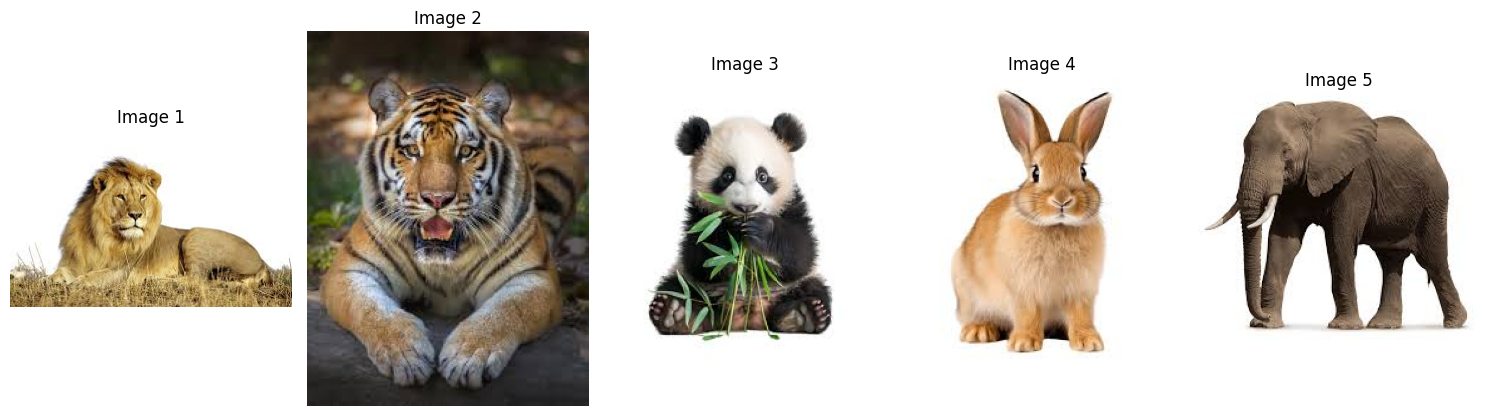

In [7]:
# visualize the original images
import matplotlib.pyplot as plt # Import the matplotlib library and assign it to the alias 'plt'

fig, axs = plt.subplots(1, len(image_list), figsize=(15, 5))

for i, img in enumerate(image_list):
    axs[i].imshow(img)
    axs[i].axis('off')
    axs[i].set_title(f'Image {i+1}')

plt.tight_layout()
plt.show()


# Feature extraction

In [9]:
# Set the folder path
dataset_path = "/content/drive/MyDrive/Machine Learning/Features Data"

In [10]:
# Print the dataset path contents to confirm
print(f"Dataset Path: {dataset_path}")
print("Contents of the dataset folder:")
print(os.listdir(dataset_path))

Dataset Path: /content/drive/MyDrive/Machine Learning/Features Data
Contents of the dataset folder:
['Lion.jpg', 'Tiger.jpg', 'Panda.jpg', 'Rabbit.jpg', 'Elephant.jpg']


Processing file: Lion.jpg


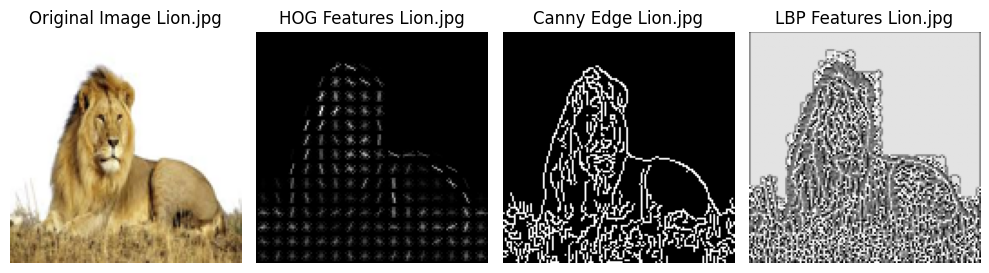

Processing file: Tiger.jpg


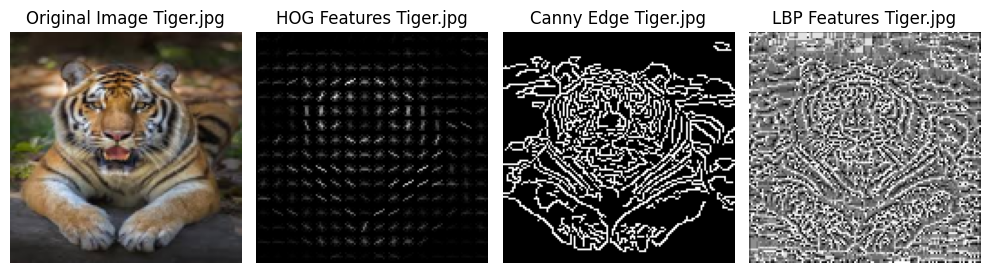

Processing file: Panda.jpg


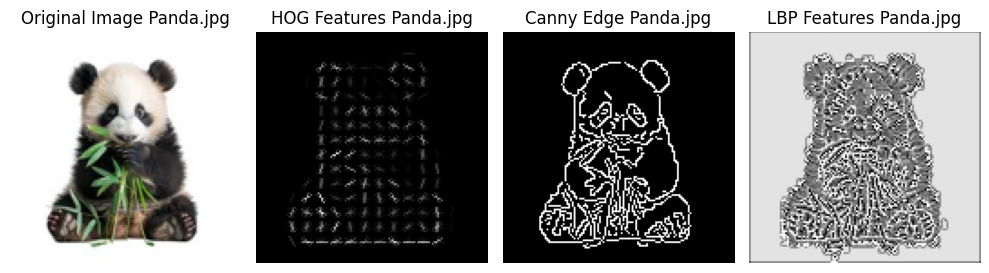

Processing file: Rabbit.jpg


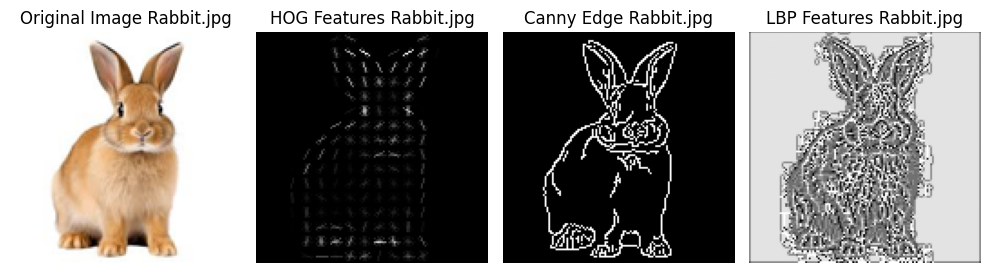

Processing file: Elephant.jpg


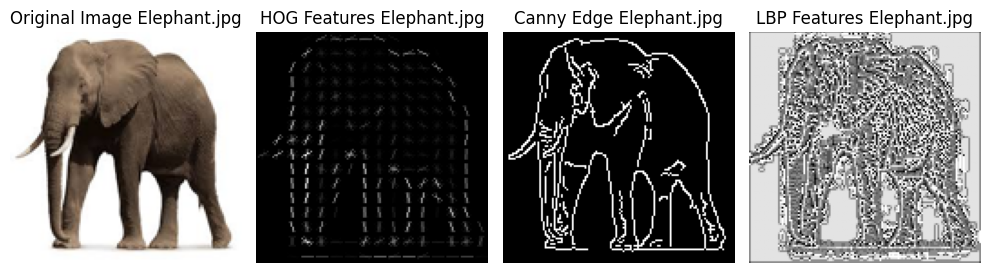

Feature extraction done!
Features shape: (5, 40868)
Labels shape: (5,)


In [12]:
import os
from google.colab import drive
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np # Import numpy
from skimage.feature import hog
from skimage.feature import local_binary_pattern
import cv2
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import VarianceThreshold, SelectKBest
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ... (rest of your code) ...

image_dir = '/content/drive/MyDrive/Machine Learning/Features Data'
features = [] #Empty list to store the extracted information from each image.
labels = []
image_list = [] # for visualization

# process image
for file in os.listdir(dataset_path):
    if file.lower().endswith(('.png', '.jpg', '.jpeg')):
        img_path = os.path.join(dataset_path, file)
        print(f"Processing file: {file}")

        img = Image.open(img_path).convert('RGB').resize((128, 128))
        image_list.append(img)

        # Convert to NumPy
        img_np = np.array(img) # Now np is defined

        # ... (rest of your code) ...

        # Feature 1: HOG
        gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
        hog_feat, hog_image = hog(gray, pixels_per_cell=(8, 8), cells_per_block=(2, 2), visualize=True)

        # Feature 2: Canny Edge Detection
        edges = cv2.Canny(gray, 100, 200)

        # Feature 3: Local Binary Patterns (LBP)
        radius = 1
        n_points = 8 * radius
        lbp = local_binary_pattern(gray, n_points, radius, method='uniform')
        lbp_image = np.uint8(lbp)

        # Combine features (HOG, Canny edges, LBP)
        combined = np.hstack((hog_feat, edges.flatten(), lbp.flatten()))
        features.append(combined)
        labels.append(file)

        # Show Original Image, HOG Features, Canny Edge Features, and LBP Features horizontally
        fig, axs = plt.subplots(1, 4, figsize=(10, 5))

        # Original Image
        axs[0].imshow(img_np)
        axs[0].axis('off')
        axs[0].set_title(f'Original Image {file}')

        # HOG Features
        axs[1].imshow(hog_image, cmap=plt.cm.gray)
        axs[1].axis('off')
        axs[1].set_title(f'HOG Features {file}')

        # Canny Edge Detection
        axs[2].imshow(edges, cmap=plt.cm.gray)
        axs[2].axis('off')
        axs[2].set_title(f'Canny Edge {file}')

        # LBP Image
        axs[3].imshow(lbp_image, cmap=plt.cm.gray)
        axs[3].axis('off')
        axs[3].set_title(f'LBP Features {file}')

        plt.tight_layout()
        plt.show()

# # Check if features and labels are being populated
# print(f"Features collected: {len(features)}")
# print(f"Labels collected: {len(labels)}")

# # Convert to arrays
features = np.array(features)
labels = np.array(labels)

# Encode labels to numbers
label_encoder = LabelEncoder()
labels_encoded = label_encoder.fit_transform(labels)

# Save the features and labels in your desired directory (ML_DATASET)
np.save("/content/drive/MyDrive/Machine Learning/Features Data/features.npy", features)
np.save("/content/drive/MyDrive/Machine Learning/Features Data/labels.npy", labels_encoded)

print("Feature extraction done!")
print("Features shape:", features.shape)
print("Labels shape:", labels.shape)

In [ ]:
# Convert list to numpy array
features_np = np.array(features)

# Print the whole feature matrix
print("Full feature matrix:")
print(features_np)
print("Feature matrix shape:", features_np.shape)


Full feature matrix:
[[0.         0.         0.         ... 2.         3.         1.        ]
 [0.06243943 0.         0.         ... 2.         3.         2.        ]
 [0.1827169  0.05575492 0.05769317 ... 5.         4.         2.        ]
 [0.22430034 0.11750305 0.11045309 ... 5.         5.         3.        ]]
Feature matrix shape: (4, 40868)


# Feature Selection and visualization


Original features shape: (5, 40868)
After VarianceThreshold: (5, 26583)
After SelectKBest: (5, 50)


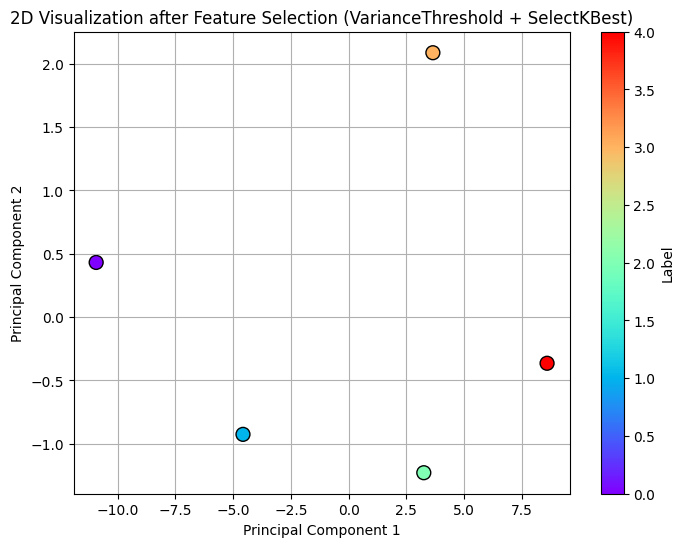

In [13]:
# Load features
features = np.load("/content/drive/MyDrive/Machine Learning/Features Data/features.npy")
labels_encoded = np.load("/content/drive/MyDrive/Machine Learning/Features Data/labels.npy")

print("Original features shape:", features.shape)

# 1. VarianceThreshold
selector_var = VarianceThreshold(threshold=0.01)
features_var = selector_var.fit_transform(features)
print("After VarianceThreshold:", features_var.shape)

# 2. SelectKBest
k_best = 50
selector_kbest = SelectKBest(mutual_info_regression, k=k_best)
features_kbest = selector_kbest.fit_transform(features_var, labels_encoded)
print("After SelectKBest:", features_kbest.shape)

# Normalize (important before PCA)
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_kbest)

# Visualize using PCA (2D)
pca = PCA(n_components=2)
features_pca = pca.fit_transform(features_scaled)

# Plot the PCA projection
plt.figure(figsize=(8,6))
scatter = plt.scatter(features_pca[:, 0], features_pca[:, 1], c=labels_encoded, cmap='rainbow', edgecolor='k', s=100)
plt.colorbar(scatter, label='Label')
plt.title('2D Visualization after Feature Selection (VarianceThreshold + SelectKBest)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()
